# RQ2: Is more intensive chatbot use related to well-being?
**Owner: Maia**

We use pandas to calculate a correlation and matplotlib to make a scatter plot. The correlation shows whether the two measures tend to go up or down together; it does not show that one causes the other.

Before saving, use *Runtime → Restart and run all* to run the notebook from top to bottom.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Choose which dataset to use: "raw" or "clean".
DATA_SOURCE = "clean"

RAW_URL = "https://raw.githubusercontent.com/SALT-NLP/AI-companionship-well-being/main/data.csv"
CLEAN_URL = "https://raw.githubusercontent.com/xMrTuffnut/ai-companion-wellbeing/main/data/clean.csv"

if DATA_SOURCE == "raw":
    data_url = RAW_URL
else:
    data_url = CLEAN_URL

df = pd.read_csv(data_url)
print("Data source:", DATA_SOURCE)
print("Dataset size:", df.shape)

Data source: raw
Dataset size: (1131, 14)


In [2]:
df[["intensity", "well_being"]].describe().T

,count,mean,std,min,25%,50%,75%,max
intensity,1131.0,0.000763,0.999583,-2.557881,-0.700432,0.164468,0.803831,1.905873
well_being,1131.0,4.789272,1.329067,1.000000,3.916667,5.000000,5.833333,7.000000


In [3]:
# Keep only the two columns we need and remove rows with missing values.
analysis_df = df[["intensity", "well_being"]].dropna()

# Pandas calculates the Pearson correlation between the two columns.
correlation = analysis_df["intensity"].corr(analysis_df["well_being"])

print("Pearson correlation:", round(correlation, 3))
print("Number of participants:", len(analysis_df))

Pearson correlation: 0.253
Number of participants: 1131


The correlation is between -1 and 1. A positive number means the two measures tend to increase together; a negative number means one tends to decrease as the other increases. A number near 0 means little linear relationship.

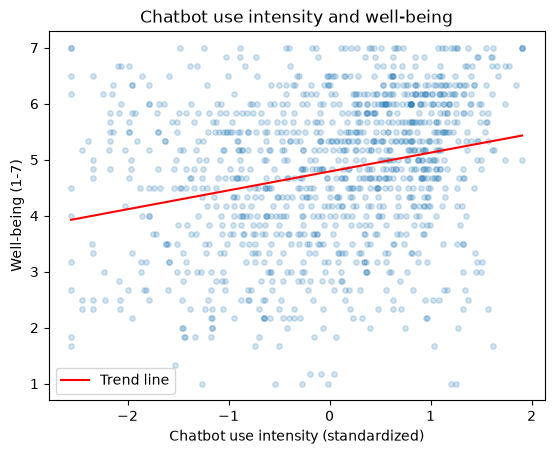

In [4]:
plt.scatter(analysis_df["intensity"], analysis_df["well_being"], alpha=0.2, s=15)

# Find the straight line that best fits the points.
slope, intercept = np.polyfit(analysis_df["intensity"], analysis_df["well_being"], 1)
x_line = np.linspace(analysis_df["intensity"].min(), analysis_df["intensity"].max(), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color="red", label="Trend line")

plt.xlabel("Chatbot use intensity (standardized)")
plt.ylabel("Well-being (1-7)")
plt.title("Chatbot use intensity and well-being")
plt.legend()
plt.show()